# 3.1 — Multi-Dataset Regression Modelling (2.1 Manual vs 2.2 UMAP/MICE)

Run the **same regression pipeline** across multiple prepared datasets and models.  
Each **(dataset × model)** pair runs in its own cell so you can execute and inspect them individually.

Datasets:
- **2.1-Manual** → `2.1-train.parquet` / `2.1-test.parquet`
- **2.2-UMAP-MICE** → `2.2-train.parquet` / `2.2-test.parquet`

Models: `LinearRegression`, `Ridge`, `Lasso`, `RandomForest`, `GradientBoosting`, `XGBoost`

> **Next step:** Analysis and explanation of the winning model is in  
> `3.2-Model-Analysis-and-Explanation.ipynb`

## Outline

| # | Section |
|---|---|
| 1 | Imports and global setup |
| 2 | Reusable pipeline factory (single model) |
| 3 | Load all datasets |
| 4 | Model registry & `run_model()` helper |
| 5 | Individual runs — one cell per (dataset × model) |
| 6 | Cross-dataset × cross-model comparison (winner table) |


## 1. Imports and Global Setup

In [12]:
import subprocess, sys

_packages = [
    'polars',
    'scikit-learn',
    'xgboost',
    'shap',
    'joblib',
    'matplotlib',
    'seaborn',
    'jinja2',        # required by pandas .style
    'numpy',
    'pandas',
]

for pkg in _packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])

print('All dependencies installed.')


All dependencies installed.


In [ ]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import polars as pl

from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import shap
except Exception:
    shap = None

pd.options.display.max_columns = 200
pd.options.display.precision   = 4

print('Libraries loaded. SHAP available:', shap is not None)


## 2. Reusable Pipeline Factory Function

`build_regression_pipeline` handles one **(dataset, model)** pair:

1. Feature / target separation (Polars-native)
2. Column type detection via Polars `.dtype` (handles `uint8`/`uint16` from Parquet)
3. `ColumnTransformer` preprocessor (median imputation → scaling / one-hot)
4. `RepeatedKFold` CV — returns CV metrics
5. Fits model on full training set → returns test metrics

**Pass any sklearn estimator** as the `model` argument.  
Polars DataFrames are only converted to pandas at the sklearn boundary (`.to_pandas()`).


In [6]:
def build_regression_pipeline(
    train_df:   pl.DataFrame,
    test_df:    pl.DataFrame,
    target:     str,
    model,                          # single sklearn estimator
    model_name: str = 'Model',
    drop_cols:  list = None,
    n_splits:   int  = 5,
    n_repeats:  int  = 3,
    random_state: int = 42,
) -> dict:
    """
    Cross-validate and evaluate ONE sklearn regression model on a Polars dataset.

    Parameters
    ----------
    train_df, test_df : pl.DataFrame
    target            : str          — target column name
    model             : sklearn estimator — pass a model from MODELS registry
    model_name        : str          — label for display / storage
    drop_cols         : list         — extra columns to exclude from features
    n_splits, n_repeats, random_state — RepeatedKFold settings

    Returns
    -------
    dict with keys:
        model_name, pipeline,
        X_train, X_test  (pl.DataFrame),
        y_train, y_test, y_pred  (np.ndarray),
        feature_names, numeric_cols, cat_cols,
        cv_mae, cv_rmse, cv_r2,
        test_mae, test_rmse, test_r2
    """
    # ── 1. Feature / target separation (Polars) ──────────────────────────────
    all_drop     = [c for c in ([target] + (drop_cols or [])) if c in train_df.columns]
    feature_cols = [c for c in train_df.columns if c not in all_drop]

    X_train = train_df.select(feature_cols)
    y_train = train_df[target].to_numpy()

    # Align test set columns to match training set columns
    X_test_aligned = pl.DataFrame()
    for col in feature_cols:
        if col in test_df.columns:
            X_test_aligned = X_test_aligned.with_columns(test_df[col])
        else:
            # Add missing column to X_test_aligned with nulls, preserving dtype
            null_series = pl.Series([None] * test_df.shape[0], dtype=X_train[col].dtype).alias(col)
            X_test_aligned = X_test_aligned.with_columns(null_series)
    # Ensure the order of columns in X_test matches X_train
    X_test = X_test_aligned.select(feature_cols)

    y_test  = test_df[target].to_numpy()

    # ── 2. Column type detection (Polars native) ──────────────────────────────
    _numeric_dtypes = {
        pl.Int8,  pl.Int16,  pl.Int32,  pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64,
    }
    _string_dtypes = {pl.Utf8, pl.String, pl.Categorical}

    numeric_cols = [c for c in X_train.columns if X_train[c].dtype in _numeric_dtypes]
    cat_cols     = [c for c in X_train.columns if X_train[c].dtype in _string_dtypes]

    print(f'  Features : {len(numeric_cols)} numeric, {len(cat_cols)} categorical')

    # ── 3. sklearn boundary: convert Polars → pandas ──────────────────────────
    X_train_pd = X_train.to_pandas()
    X_test_pd  = X_test.to_pandas()

    # ── 4. Preprocessor ───────────────────────────────────────────────────────
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    transformers = []
    if numeric_cols:
        transformers.append(('num', numeric_transformer, numeric_cols))
    if cat_cols:
        cat_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ])
        transformers.append(('cat', cat_transformer, cat_cols))

    if not transformers:
        raise ValueError('No numeric or categorical columns found.')

    preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

    # ── 5. RepeatedKFold cross-validation (single model) ─────────────────────
    cv      = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    scoring = {
        'MAE':  'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2':   'r2',
    }
    pipe   = Pipeline([('pre', preprocessor), ('model', model)])
    cv_res = cross_validate(pipe, X_train_pd, y_train, cv=cv, scoring=scoring,
                            n_jobs=-1, return_train_score=False)

    cv_mae  = float(-cv_res['test_MAE'].mean())
    cv_rmse = float(-cv_res['test_RMSE'].mean())
    cv_r2   = float(cv_res['test_R2'].mean())
    print(f'  CV  : MAE={cv_mae:.4f}  RMSE={cv_rmse:.4f}  R²={cv_r2:.4f}')

    # ── 6. Fit on full training set ───────────────────────────────────────────
    pipeline = Pipeline([('pre', preprocessor), ('model', model)])
    pipeline.fit(X_train_pd, y_train)

    # ── 7. Test-set evaluation ────────────────────────────────────────────────
    y_pred    = pipeline.predict(X_test_pd)
    test_mae  = float(mean_absolute_error(y_test, y_pred))
    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    test_r2   = float(r2_score(y_test, y_pred))
    print(f'  Test: MAE={test_mae:.4f}  RMSE={test_rmse:.4f}  R²={test_r2:.4f}')

    # ── 8. Feature names after one-hot expansion ──────────────────────────────
    onehot_cols = []
    if cat_cols:
        enc = pipeline.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
        onehot_cols = enc.get_feature_names_out(cat_cols).tolist()
    feature_names = numeric_cols + onehot_cols

    return {
        'model_name':    model_name,
        'pipeline':      pipeline,
        'X_train':       X_train,       # pl.DataFrame
        'X_test':        X_test,        # pl.DataFrame
        'y_train':       y_train,       # np.ndarray
        'y_test':        y_test,        # np.ndarray
        'y_pred':        y_pred,        # np.ndarray
        'feature_names': feature_names,
        'numeric_cols':  numeric_cols,
        'cat_cols':      cat_cols,
        'cv_mae':        cv_mae,   'cv_rmse':   cv_rmse,   'cv_r2':   cv_r2,
        'test_mae':      test_mae, 'test_rmse': test_rmse, 'test_r2': test_r2,
    }

## 3. Load All Datasets

Add or remove entries in `DATASETS` to compare more pipelines.  
Each entry maps a label to its local train/test parquet paths.


In [7]:
# ── Dataset registry — add/remove entries freely ─────────────────────────────
DATASETS = {
    '2.1-Manual': {
        'train_path': 'https://raw.githubusercontent.com/LALITAMITTAL18/EAISI-NHS/main/notebooks/Experiment/Knee/data/interim/2.1-train.parquet',
        'test_path':  'https://raw.githubusercontent.com/LALITAMITTAL18/EAISI-NHS/main/notebooks/Experiment/Knee/data/interim/2.1-test.parquet',
    },
    '2.2-UMAP-MICE': {
        'train_path': 'https://raw.githubusercontent.com/LALITAMITTAL18/EAISI-NHS/main/notebooks/Experiment/Knee/data/interim/2.2-train.parquet',
        'test_path':  'https://raw.githubusercontent.com/LALITAMITTAL18/EAISI-NHS/main/notebooks/Experiment/Knee/data/interim/2.1-test.parquet',
    },
}

TARGET = 'health_gain'

# ── Load each dataset as Polars DataFrames ────────────────────────────────────
all_data = {}   # label -> (train_pl, test_pl, drop_cols)

for label, paths in DATASETS.items():
    train_pl  = pl.read_parquet(paths['train_path'])
    test_pl   = pl.read_parquet(paths['test_path'])
    drop_cols = ['OHS_Success'] if 'OHS_Success' in train_pl.columns else []
    all_data[label] = (train_pl, test_pl, drop_cols)
    print(f'{label:20s}  train={train_pl.shape}  test={test_pl.shape}  drop={drop_cols}')

print(f'\nTarget : {TARGET}')
print(f'Loaded : {list(all_data.keys())}')


2.1-Manual            train=(94550, 46)  test=(23638, 46)  drop=[]
2.2-UMAP-MICE         train=(111388, 47)  test=(23638, 46)  drop=[]

Target : health_gain
Loaded : ['2.1-Manual', '2.2-UMAP-MICE']


## 4. Model Registry & Runner

`MODELS` is the single source of truth for all candidate estimators, including XGBoost.  
`run_model(dataset_label, model_name)` runs one pair and stores the result — call it in any cell below.


In [25]:
# ── Model registry ────────────────────────────────────────────────────────────
from sklearn.ensemble import HistGradientBoostingRegressor

try:
    from xgboost import XGBRegressor
    _xgb_available = True
except ImportError:
    _xgb_available = False

MODELS = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(alpha=1.0, random_state=42),
    'Lasso':            Lasso(alpha=0.01, random_state=42, max_iter=10_000),
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    # HistGradientBoosting is ~10× faster than GradientBoostingRegressor
    # (uses histogram binning + native missing value support, no n_estimators limit issue)
    'GradientBoosting': HistGradientBoostingRegressor(max_iter=300, random_state=42),
}
if _xgb_available:
    MODELS['XGBoost'] = XGBRegressor(
        n_estimators=300, learning_rate=0.05, subsample=0.8,
        random_state=42, n_jobs=-1, verbosity=0,
    )

print(f'Models available: {list(MODELS.keys())}')

# ── Persistent results cache ───────────────────────────────────────────────────
RESULTS_PATH = Path('./models/all_results_cache.joblib')
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

if RESULTS_PATH.exists():
    all_results = joblib.load(RESULTS_PATH)
    print(f'\nLoaded cached results from {RESULTS_PATH}:')
    for ds, models_dict in all_results.items():
        for mdl, r in models_dict.items():
            print(f'  ✓  {ds:20s} × {mdl:<20s}  Test RMSE={r["test_rmse"]:.4f}  R²={r["test_r2"]:.4f}')
else:
    all_results = {}
    print(f'\nNo cache found at {RESULTS_PATH} — starting fresh.')

# ── Runner — always re-runs and overwrites ────────────────────────────────────
def run_model(dataset_label: str, model_name: str) -> dict:
    """
    Run one (dataset × model) pair, overwrite its cache entry, and persist to disk.
    Running the same cell again will always re-train and overwrite.
    """
    if model_name not in MODELS:
        raise ValueError(f"Unknown model '{model_name}'. Available: {list(MODELS.keys())}")

    action = 'overwriting' if model_name in all_results.get(dataset_label, {}) else 'new'
    print(f'▶  {dataset_label}  ×  {model_name}  ({action})')

    train_pl, test_pl, drop_cols = all_data[dataset_label]
    result = build_regression_pipeline(
        train_pl, test_pl, target=TARGET,
        model=MODELS[model_name], model_name=model_name,
        drop_cols=drop_cols,
    )

    all_results.setdefault(dataset_label, {})[model_name] = result
    joblib.dump(all_results, RESULTS_PATH)
    print(f'  ✓ Cache saved → {RESULTS_PATH}')
    return result

print('run_model() defined — every call re-trains and overwrites the cache entry.')


Models available: ['LinearRegression', 'Ridge', 'Lasso', 'RandomForest', 'GradientBoosting', 'XGBoost']

Loaded cached results from models\all_results_cache.joblib:
  ✓  2.1-Manual           × LinearRegression      Test RMSE=8.1271  R²=0.3136
  ✓  2.1-Manual           × Ridge                 Test RMSE=8.1245  R²=0.3141
  ✓  2.1-Manual           × Lasso                 Test RMSE=8.1271  R²=0.3137
  ✓  2.1-Manual           × RandomForest          Test RMSE=5.6459  R²=0.6688
  ✓  2.1-Manual           × GradientBoosting      Test RMSE=5.5348  R²=0.6817
  ✓  2.1-Manual           × XGBoost               Test RMSE=5.5349  R²=0.6817
  ✓  2.2-UMAP-MICE        × LinearRegression      Test RMSE=8.8854  R²=0.1796
  ✓  2.2-UMAP-MICE        × Ridge                 Test RMSE=8.8815  R²=0.1803
  ✓  2.2-UMAP-MICE        × Lasso                 Test RMSE=8.8798  R²=0.1806
  ✓  2.2-UMAP-MICE        × XGBoost               Test RMSE=8.7987  R²=0.1955
run_model() defined — every call re-trains and overwrit

## 5. Individual Runs — Dataset × Model

Each cell below runs **one (dataset, model) pair** independently.  
Run them selectively or all at once. Results accumulate in `all_results`.

> **Tip:** To add a new model, add it to `MODELS` in the cell above, then add a `run_model(...)` cell here.


### Dataset: 2.1-Manual


In [9]:
run_model('2.1-Manual', 'LinearRegression')


▶  2.1-Manual  ×  LinearRegression  (new)
  Features : 44 numeric, 1 categorical
  CV  : MAE=6.3330  RMSE=8.0894  R²=0.3151
  Test: MAE=6.3602  RMSE=8.1271  R²=0.3136
  ✓ Cache saved → models\all_results_cache.joblib


{'model_name': 'LinearRegression',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Provider Code', 'Procedure',
                                                    'Revision Flag', 'Year',
                                                    'Age Band', 'Gender',
                                                    'Pre-Op Q Assisted',
                                                    'Pre-Op Q Assisted By',
                                                    'Pre-Op Q Symptom Period',
                                                    'Pre-Op 

In [10]:
run_model('2.1-Manual', 'Ridge')


▶  2.1-Manual  ×  Ridge  (new)
  Features : 44 numeric, 1 categorical
  CV  : MAE=6.3310  RMSE=8.0862  R²=0.3156
  Test: MAE=6.3583  RMSE=8.1245  R²=0.3141
  ✓ Cache saved → models\all_results_cache.joblib


{'model_name': 'Ridge',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Provider Code', 'Procedure',
                                                    'Revision Flag', 'Year',
                                                    'Age Band', 'Gender',
                                                    'Pre-Op Q Assisted',
                                                    'Pre-Op Q Assisted By',
                                                    'Pre-Op Q Symptom Period',
                                                    'Pre-Op Q Previous 

In [11]:
run_model('2.1-Manual', 'Lasso')


▶  2.1-Manual  ×  Lasso  (new)
  Features : 44 numeric, 1 categorical
  CV  : MAE=6.3333  RMSE=8.0860  R²=0.3156
  Test: MAE=6.3615  RMSE=8.1271  R²=0.3137
  ✓ Cache saved → models\all_results_cache.joblib


{'model_name': 'Lasso',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Provider Code', 'Procedure',
                                                    'Revision Flag', 'Year',
                                                    'Age Band', 'Gender',
                                                    'Pre-Op Q Assisted',
                                                    'Pre-Op Q Assisted By',
                                                    'Pre-Op Q Symptom Period',
                                                    'Pre-Op Q Previous 

In [15]:
run_model('2.1-Manual', 'RandomForest')


▶  2.1-Manual  ×  RandomForest  (new)
  Features : 44 numeric, 1 categorical


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
11 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
  File "c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
  File "c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.ve

  CV  : MAE=nan  RMSE=nan  R²=nan
  Test: MAE=4.2090  RMSE=5.6459  R²=0.6688
  ✓ Cache saved → models\all_results_cache.joblib


{'model_name': 'RandomForest',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Provider Code', 'Procedure',
                                                    'Revision Flag', 'Year',
                                                    'Age Band', 'Gender',
                                                    'Pre-Op Q Assisted',
                                                    'Pre-Op Q Assisted By',
                                                    'Pre-Op Q Symptom Period',
                                                    'Pre-Op Q Pr

In [16]:
run_model('2.1-Manual', 'GradientBoosting')


▶  2.1-Manual  ×  GradientBoosting  (new)
  Features : 44 numeric, 1 categorical
  CV  : MAE=4.1004  RMSE=5.5055  R²=0.6827
  Test: MAE=4.1231  RMSE=5.5348  R²=0.6817
  ✓ Cache saved → models\all_results_cache.joblib


{'model_name': 'GradientBoosting',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Provider Code', 'Procedure',
                                                    'Revision Flag', 'Year',
                                                    'Age Band', 'Gender',
                                                    'Pre-Op Q Assisted',
                                                    'Pre-Op Q Assisted By',
                                                    'Pre-Op Q Symptom Period',
                                                    'Pre-Op 

In [20]:
run_model('2.1-Manual', 'XGBoost')


▶  2.1-Manual  ×  XGBoost  (new)
  Features : 44 numeric, 1 categorical
  CV  : MAE=4.0949  RMSE=5.5203  R²=0.6810
  Test: MAE=4.1085  RMSE=5.5349  R²=0.6817
  ✓ Cache saved → models\all_results_cache.joblib


{'model_name': 'XGBoost',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Provider Code', 'Procedure',
                                                    'Revision Flag', 'Year',
                                                    'Age Band', 'Gender',
                                                    'Pre-Op Q Assisted',
                                                    'Pre-Op Q Assisted By',
                                                    'Pre-Op Q Symptom Period',
                                                    'Pre-Op Q Previou

### Dataset: 2.2-UMAP-MICE


In [12]:
run_model('2.2-UMAP-MICE', 'LinearRegression')


▶  2.2-UMAP-MICE  ×  LinearRegression  (new)
  Features : 45 numeric, 1 categorical
  CV  : MAE=4.3146  RMSE=5.9719  R²=0.6360
  Test: MAE=7.0424  RMSE=8.8854  R²=0.1796
  ✓ Cache saved → models\all_results_cache.joblib


{'model_name': 'LinearRegression',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Arthritis', 'Cancer',
                                                    'Circulation', 'Depression',
                                                    'Diabetes', 'Heart Disease',
                                                    'High Bp', 'Kidney Disease',
                                                    'Liver Disease',
                                                    'Lung Disease',
                                                    'Nervous Syste

In [13]:
run_model('2.2-UMAP-MICE', 'Ridge')


▶  2.2-UMAP-MICE  ×  Ridge  (new)
  Features : 45 numeric, 1 categorical
  CV  : MAE=4.2908  RMSE=5.8315  R²=0.6529
  Test: MAE=7.0396  RMSE=8.8815  R²=0.1803
  ✓ Cache saved → models\all_results_cache.joblib


{'model_name': 'Ridge',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Arthritis', 'Cancer',
                                                    'Circulation', 'Depression',
                                                    'Diabetes', 'Heart Disease',
                                                    'High Bp', 'Kidney Disease',
                                                    'Liver Disease',
                                                    'Lung Disease',
                                                    'Nervous System', 'Stroke

In [14]:
run_model('2.2-UMAP-MICE', 'Lasso')


▶  2.2-UMAP-MICE  ×  Lasso  (new)
  Features : 45 numeric, 1 categorical
  CV  : MAE=4.2865  RMSE=5.8257  R²=0.6536
  Test: MAE=7.0425  RMSE=8.8798  R²=0.1806
  ✓ Cache saved → models\all_results_cache.joblib


{'model_name': 'Lasso',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Arthritis', 'Cancer',
                                                    'Circulation', 'Depression',
                                                    'Diabetes', 'Heart Disease',
                                                    'High Bp', 'Kidney Disease',
                                                    'Liver Disease',
                                                    'Lung Disease',
                                                    'Nervous System', 'Stroke

In [ ]:
run_model('2.2-UMAP-MICE', 'RandomForest')


▶  2.2-UMAP-MICE  ×  RandomForest
  Features : 45 numeric, 1 categorical


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  CV  : MAE=3.9921  RMSE=5.3897  R²=0.7035
  Test: MAE=6.9642  RMSE=8.9856  R²=0.1610


{'model_name': 'RandomForest',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Arthritis', 'Cancer',
                                                    'Circulation', 'Depression',
                                                    'Diabetes', 'Heart Disease',
                                                    'High Bp', 'Kidney Disease',
                                                    'Liver Disease',
                                                    'Lung Disease',
                                                    'Nervous System', 

In [22]:
run_model('2.2-UMAP-MICE', 'GradientBoosting')


▶  2.2-UMAP-MICE  ×  GradientBoosting  (new)
  Features : 45 numeric, 1 categorical


KeyboardInterrupt: 

In [21]:
run_model('2.2-UMAP-MICE', 'XGBoost')


▶  2.2-UMAP-MICE  ×  XGBoost  (new)
  Features : 45 numeric, 1 categorical
  CV  : MAE=3.8737  RMSE=5.2537  R²=0.7183
  Test: MAE=6.7780  RMSE=8.7987  R²=0.1955
  ✓ Cache saved → models\all_results_cache.joblib


{'model_name': 'XGBoost',
 'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Arthritis', 'Cancer',
                                                    'Circulation', 'Depression',
                                                    'Diabetes', 'Heart Disease',
                                                    'High Bp', 'Kidney Disease',
                                                    'Liver Disease',
                                                    'Lung Disease',
                                                    'Nervous System', 'Stro

## 6. Compare All Results

Collect every (dataset × model) result stored in `all_results` and find the overall winner.  
The best row (lowest Test RMSE) is highlighted in green — downstream sections use that pipeline.


Loaded cached results (10 runs) from models\all_results_cache.joblib
=== Full Comparison: Dataset × Model ===



,Dataset,Model,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²
0,2.1-Manual,GradientBoosting,5.505500,0.682700,4.123100,5.534800,0.681700
1,2.1-Manual,XGBoost,5.520300,0.681000,4.108500,5.534900,0.681700
2,2.1-Manual,RandomForest,nan,nan,4.209000,5.645900,0.668800
3,2.1-Manual,Ridge,8.086200,0.315600,6.358300,8.124500,0.314100
4,2.1-Manual,Lasso,8.086000,0.315600,6.361500,8.127100,0.313700
5,2.1-Manual,LinearRegression,8.089400,0.315100,6.360200,8.127100,0.313600
6,2.2-UMAP-MICE,XGBoost,5.253700,0.718300,6.778000,8.798700,0.195500
7,2.2-UMAP-MICE,Lasso,5.825700,0.653600,7.042500,8.879800,0.180600
8,2.2-UMAP-MICE,Ridge,5.831500,0.652900,7.039600,8.881500,0.180300
9,2.2-UMAP-MICE,LinearRegression,5.971900,0.636000,7.042400,8.885400,0.179600


C:\Users\mittall\AppData\Local\Temp\ipykernel_20928\3091875810.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax, data=comparison_df, x='Label', y=metric, palette=colors)
C:\Users\mittall\AppData\Local\Temp\ipykernel_20928\3091875810.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax, data=comparison_df, x='Label', y=metric, palette=colors)
C:\Users\mittall\AppData\Local\Temp\ipykernel_20928\3091875810.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax, data=comparison_df, x='Label', y=metric, palette=colors)


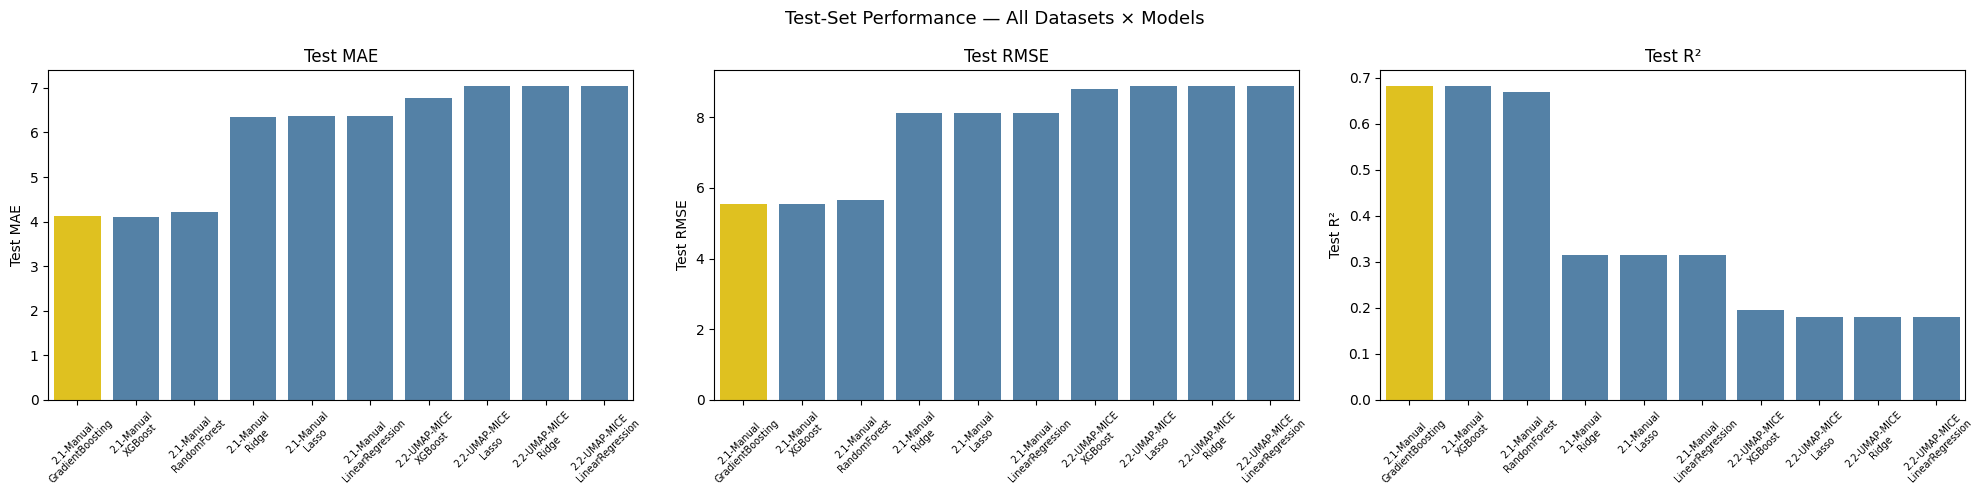


>>> OVERALL WINNER
    Dataset  : 2.1-Manual
    Model    : GradientBoosting
    Test RMSE: 5.5348  |  Test R²: 0.6817

Sections 7–10 will use: dataset=2.1-Manual, model=GradientBoosting


In [7]:

# ── Self-contained imports (safe to re-run even if Section 1 was skipped) ─────
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Guard: recover all_results from cache if not in scope ─────────────────────
_RESULTS_PATH = Path('./models/all_results_cache.joblib')

if 'all_results' not in dir() or not all_results:
    if _RESULTS_PATH.exists():
        all_results = joblib.load(_RESULTS_PATH)
        print(f'Loaded cached results ({sum(len(v) for v in all_results.values())} runs) from {_RESULTS_PATH}')
    else:
        raise RuntimeError(
            "No results found in scope or on disk.\n"
            "Run cells 1–5 first (Imports → Pipeline factory → Load datasets → "
            "Model registry → Individual runs) before running this comparison cell."
        )

if not all_results:
    raise RuntimeError(
        "all_results is empty — run at least one run_model() cell in Section 5 first."
    )

# ── Flatten all_results into a comparison table ───────────────────────────────
comparison_rows = []
for ds_label, models_dict in all_results.items():
    for mdl_name, res in models_dict.items():
        comparison_rows.append({
            'Dataset':   ds_label,
            'Model':     mdl_name,
            'CV RMSE':   round(res['cv_rmse'],   4),
            'CV R²':     round(res['cv_r2'],      4),
            'Test MAE':  round(res['test_mae'],   4),
            'Test RMSE': round(res['test_rmse'],  4),
            'Test R²':   round(res['test_r2'],    4),
        })

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values('Test RMSE')
    .reset_index(drop=True)
)

def highlight_winner(s):
    return ['background-color: #d4edda; font-weight: bold'
            if i == 0 else '' for i in range(len(s))]

print('=== Full Comparison: Dataset × Model ===\n')
display(comparison_df.style.apply(highlight_winner, axis=0))

# ── Bar charts ────────────────────────────────────────────────────────────────
comparison_df['Label'] = comparison_df['Dataset'] + '\n' + comparison_df['Model']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Test-Set Performance — All Datasets × Models', fontsize=13)

winner_label = comparison_df.iloc[0]['Label']
for ax, metric in zip(axes, ['Test MAE', 'Test RMSE', 'Test R²']):
    colors = ['gold' if lbl == winner_label else 'steelblue'
              for lbl in comparison_df['Label']]
    sns.barplot(ax=ax, data=comparison_df, x='Label', y=metric, palette=colors)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

# ── Announce overall winner ───────────────────────────────────────────────────
winner_row   = comparison_df.iloc[0]
best_dataset = winner_row['Dataset']
best_name    = winner_row['Model']

print(f'\n>>> OVERALL WINNER')
print(f'    Dataset  : {best_dataset}')
print(f'    Model    : {best_name}')
print(f'    Test RMSE: {winner_row["Test RMSE"]}  |  Test R²: {winner_row["Test R²"]}')

# ── Expose winner objects for downstream cells ────────────────────────────────
best_res      = all_results[best_dataset][best_name]
best_pipeline = best_res['pipeline']
X_train       = best_res['X_train']
X_test        = best_res['X_test']
y_train       = best_res['y_train']
y_test        = best_res['y_test']
y_pred        = best_res['y_pred']
feature_names = best_res['feature_names']
numeric_cols  = best_res['numeric_cols']
cat_cols      = best_res['cat_cols']

print(f'\nSections 7–10 will use: dataset={best_dataset}, model={best_name}')
